- **Nama:** Difa Fisabilillah
- **Email:** difafisabilillah91@gmail.com
- **ID Dicoding:** MC401D5X0255

# **1. Import Library**

In [ ]:
!pip install category_encoders
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.5 MB/s eta 0:00:00


In [ ]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from category_encoders import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import numpy as np
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical


# **2. Memuat Dataset dari Hasil Clustering**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd './drive/MyDrive/Dicoding/Project 2/'

/content/drive/MyDrive/Dicoding/Project 2


In [ ]:
df = pd.read_csv('./Dataset_inisiasi.csv')

# **3. Data Splitting**

In [ ]:
le = OrdinalEncoder()
df_encode = le.fit_transform(df)

In [ ]:
X = df_encode.iloc[:, :-1]
y = df_encode.iloc[:, -1]

In [ ]:
X.head()

,age_group,club_member_status,fashion_news_frequency,product_group_name,price
0,1,1,1,1,186.75
1,1,1,2,2,103.09
2,1,1,1,3,239.04
3,1,1,1,4,134.46
4,1,2,1,5,134.46


In [ ]:
y.head()

,clusters
0,1
1,3
2,1
3,1
4,4


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train_scale = pd.DataFrame(X_train, columns=X.columns)
X_test_scale = pd.DataFrame(X_test, columns=X.columns)

# **4. Membangun Model Klasifikasi**


Sebelum memutuskan model apa yang akan digunakan dilakukan pengujiam terlebih dahulu dengan cross validation unutk mengetahui data lebih cocok menggunakan model yang mana

In [42]:
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()
svm = SVC()
rf = RandomForestClassifier()
nb = GaussianNB()
lg = LogisticRegression()

In [43]:
score_knn = cross_val_score(knn, X_train_scale, y_train, cv=5)
score_dt = cross_val_score(dt, X_train_scale, y_train, cv=5)
score_svm = cross_val_score(svm, X_train_scale, y_train, cv=5)
score_rf = cross_val_score(rf, X_train_scale, y_train, cv=5)
score_nb = cross_val_score(nb, X_train_scale, y_train, cv=5)
score_lg = cross_val_score(lg, X_train_scale, y_train, cv=5)


In [44]:
print(f'KNeighborsClassifier : {score_knn.mean()}')
print(f'DecisionTreeClassifier : {score_dt.mean()}')
print(f'SVM : {score_svm.mean()}')
print(f'RandomForestClassifier : {score_rf.mean()}')
print(f'Naive Bayes : {score_nb.mean()}')
print(f'Logistic Regression : {score_lg.mean()}')

KNeighborsClassifier : 0.9018626660357647
DecisionTreeClassifier : 0.8681949928090742
SVM : 0.8963924956583089
RandomForestClassifier : 0.9016022705687616
Naive Bayes : 0.7145091557106806
Logistic Regression : 0.8872105185946488


Pada hasil pengujian dengan cross-validation, terlihat bahwa model KNN dan Random Forest adalah 2 model yang memiliki akurasi paling besar diantara yang lain. DImana KNN menghasilkan akurasi 90% dan Random Forest menghasilkan akurasi 89,9%

## **a. Membangun Model Klasifikasi**

In [ ]:
knn = KNeighborsClassifier().fit(X_train_scale, y_train)

In [ ]:
rf = RandomForestClassifier().fit(X_train_scale, y_train)

Di sini dipilih model KNN dan Random Forest.
1. KNN dipilih karena mengasilkan akurasi paling tinggi di banding model lainnya karena mengahasilkan akurasi sebesar 90%.
2. Model kedua atau model pembandingnya adalah Random Forest, model ini dipilih karena menghasilkan akurasi tertinggi kedua setelah KNN yaitu dengan akurasi 89,9%.

## **b. Evaluasi Model Klasifikasi**

### Evaluasi Data Training KNN

Classification matrik
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      3108
           1       0.93      0.93      0.93      5116
           2       1.00      1.00      1.00       331
           3       0.91      0.93      0.92      3600
           4       0.89      0.89      0.89      3201

    accuracy                           0.91     15356
   macro avg       0.93      0.93      0.93     15356
weighted avg       0.91      0.91      0.91     15356

Accuracy : 0.91


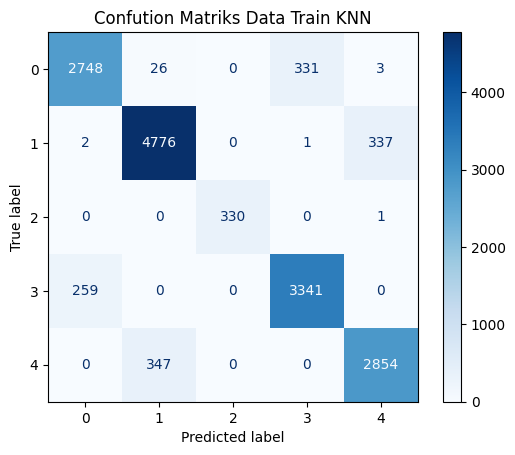

In [ ]:
y_pred_knn = knn.predict(X_train_scale)
con_metric = confusion_matrix(y_train, y_pred_knn)
print('Classification matrik')
print(classification_report(y_train, y_pred_knn))
accuracy = accuracy_score(y_train, y_pred_knn)
print(f'Accuracy : {accuracy:.2f}')
matriks = ConfusionMatrixDisplay(confusion_matrix=con_metric, display_labels = knn.classes_)
matriks.plot(cmap='Blues')
plt.title('Confution Matriks Data Train KNN')
plt.show()

### Evaluasi Data Test KNN

Classification matrik
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       745
           1       0.93      0.92      0.93      1298
           2       1.00      1.00      1.00        82
           3       0.90      0.92      0.91       902
           4       0.88      0.90      0.89       813

    accuracy                           0.91      3840
   macro avg       0.92      0.92      0.92      3840
weighted avg       0.91      0.91      0.91      3840

Accuracy : 0.91


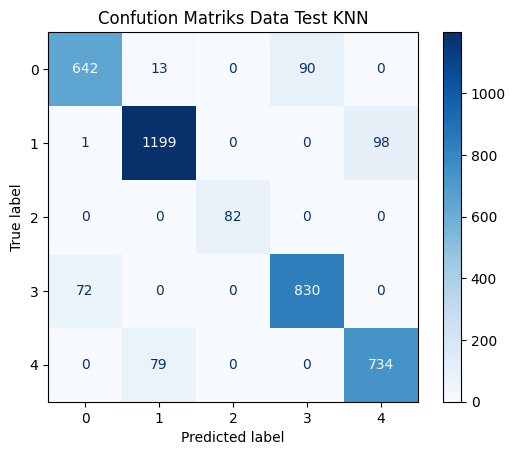

In [ ]:
y_pred_knn = knn.predict(X_test_scale)
con_metric = confusion_matrix(y_test, y_pred_knn)
print('Classification matrik')
print(classification_report(y_test, y_pred_knn))
accuracy = accuracy_score(y_test, y_pred_knn)
print(f'Accuracy : {accuracy:.2f}')
matriks = ConfusionMatrixDisplay(confusion_matrix=con_metric, display_labels = knn.classes_)
matriks.plot(cmap='Blues')
plt.title('Confution Matriks Data Test KNN')
plt.show()

### Evaluasi Data Train Random Forest

Classification matrik
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      3108
           1       0.96      0.97      0.97      5116
           2       1.00      1.00      1.00       331
           3       0.95      0.97      0.96      3600
           4       0.95      0.94      0.95      3201

    accuracy                           0.96     15356
   macro avg       0.97      0.97      0.97     15356
weighted avg       0.96      0.96      0.96     15356

Accuracy : 0.96


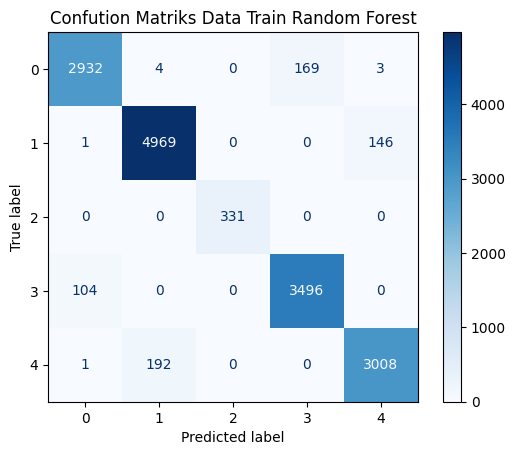

In [ ]:
y_pred_rf = rf.predict(X_train_scale)
con_metric = confusion_matrix(y_train, y_pred_rf)
print('Classification matrik')
print(classification_report(y_train, y_pred_rf))
accuracy = accuracy_score(y_train, y_pred_rf)
print(f'Accuracy : {accuracy:.2f}')
matriks = ConfusionMatrixDisplay(confusion_matrix=con_metric, display_labels = rf.classes_)
matriks.plot(cmap='Blues')
plt.title('Confution Matriks Data Train Random Forest')
plt.show()

### Evaluasi Data Test Random Forest

Classification matrik
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       745
           1       0.93      0.92      0.92      1298
           2       0.99      1.00      0.99        82
           3       0.92      0.91      0.92       902
           4       0.87      0.88      0.88       813

    accuracy                           0.91      3840
   macro avg       0.92      0.92      0.92      3840
weighted avg       0.91      0.91      0.91      3840

Accuracy : 0.91


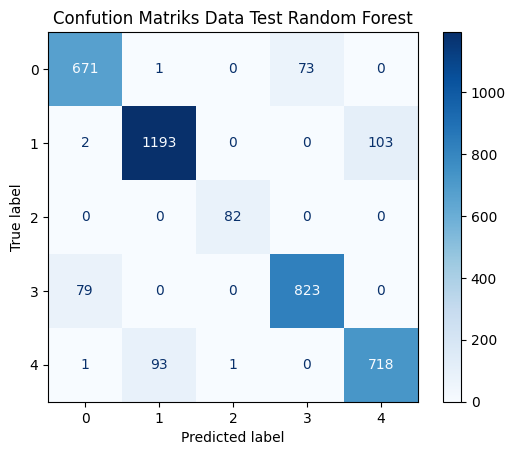

In [ ]:
y_pred_rf = rf.predict(X_test_scale)
con_metric = confusion_matrix(y_test, y_pred_rf)
print('Classification matrik')
print(classification_report(y_test, y_pred_rf))
accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy : {accuracy:.2f}')
matriks = ConfusionMatrixDisplay(confusion_matrix=con_metric, display_labels = rf.classes_)
matriks.plot(cmap='Blues')
plt.title('Confution Matriks Data Test Random Forest')
plt.show()

## **Insight : Evaluasi** <br>
1. KNN
 - Model KNN menunjukkan akurasi sebesar 91% pada data training dan testing, yang menunjukkan bahwa model memiliki kinerja yang konsisten dan tidak mengalami overfitting. Hal ini menandakan bahwa model mampu melakukan generalisasi dengan baik terhadap data baru.
 - Dari sisi evaluasi per kelas, nilai precision dan recall pada data training dan testing memiliki kecenderungan yang serupa karena perbedaan nilai dari keduanya tidak jauh berbeda.
    * Pada kelas 0 : Precision lebih tinggi, Model cenderung menghindari false positive tapi masih ada beberapa false negative.
    * Pada kelas 1 : Seimbang, Model sangat baik dalam mengenali kelas ini. Meskipun pada evaluasi di data test pada recall lebih rendah, ini masih bisa dibilang seimbang karena perbedaan sangat kecil yaitu 1.
    * Pada Kelas 2 : Sempurna, Tidak ada kesalahan prediksi untuk kelas ini.
    * pada Kelas 3 : Recall lebih tinggi,  Model sangat mampu menangkap kelas ini, meskipun sedikit false positive.
    * Pada kelas 4 : Seimbang, performa stabil untuk kelas ini, tetapi pada data testing nilai precision mengalami sedikit penurunan menjadi 0.88, meskipun recall justru meningkat menjadi 0.90. Hal ini menunjukkan bahwa model masih cukup baik dalam mengenali kelas 4, namun cenderung sedikit lebih banyak memberikan prediksi positif yang tidak tepat untuk kelas ini.


2. Random Forest
 - Terdapat perbedaan antara hasil evaluasi pada data training dan data testing, di mana akurasi pada data training mencapai 96%, sedangkan pada data testing sebesar 91%. Meskipun terdapat selisih, perbedaan ini masih dalam batas yang wajar dan menunjukkan bahwa model memiliki kemampuan generalisasi yang baik. Dengan demikian, model tidak mengalami overfitting maupun underfitting, karena performanya tetap tinggi dan stabil pada kedua dataset.
 - Sama halnya dengan evaluasi dengan KNN, evaluasi dengan Random forest pada recall dan presicion nya masih seimbang bahkan lebih tinggi dari pada evaluasi dengan KNN. Meskipun akurasi mengalami penururan pada data testing, tetapi peforma dari presisi dan recall dari semua kelas seimbang karena nilainya sama.
    


## **c. Tuning Model Klasifikasi (Optional)**

karena akurasi dari kedua model masih 91%, dilakukan hyperparameter unutk meningkatkan performa dari kedua model

In [ ]:
knn = KNeighborsClassifier()
param_knn = {
    'n_neighbors': np.arange(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
random_search_knn = RandomizedSearchCV(knn, param_distributions=param_knn, n_iter=100, cv=5, random_state=42, n_jobs=-1)
random_search_knn.fit(X_train_scale, y_train)
print("Best parameters for KNN:")
print(random_search_knn.best_params_)
print("Classification Report for KNN:")
y_pred_knn = random_search_knn.predict(X_test_scale)
print(classification_report(y_test, y_pred_knn))

Best parameters for KNN:
{'weights': 'uniform', 'n_neighbors': np.int64(9), 'metric': 'manhattan'}
Classification Report for KNN:
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       745
           1       0.92      0.93      0.92      1298
           2       1.00      1.00      1.00        82
           3       0.90      0.93      0.92       902
           4       0.89      0.89      0.89       813

    accuracy                           0.91      3840
   macro avg       0.92      0.92      0.92      3840
weighted avg       0.91      0.91      0.91      3840



In [39]:
rf = RandomForestClassifier(random_state=42)

param_rf = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

random_search_rf = RandomizedSearchCV(rf, param_distributions=param_rf, n_iter=20, cv=5, random_state=42, n_jobs=-1)
random_search_rf.fit(X_train_scale, y_train)

print("\nBest parameters for Random Forest:")
print(random_search_rf.best_params_)
print("Classification Report for Random Forest:")
y_pred_rf = random_search_rf.predict(X_test_scale)
print(classification_report(y_test, y_pred_rf))



Best parameters for Random Forest:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10, 'bootstrap': False}
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       745
           1       0.95      0.93      0.94      1298
           2       1.00      1.00      1.00        82
           3       0.93      0.94      0.93       902
           4       0.90      0.92      0.91       813

    accuracy                           0.93      3840
   macro avg       0.94      0.94      0.94      3840
weighted avg       0.93      0.93      0.93      3840



# **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Classification matrik
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       745
           1       0.93      0.93      0.93      1298
           2       1.00      1.00      1.00        82
           3       0.90      0.93      0.92       902
           4       0.89      0.90      0.89       813

    accuracy                           0.91      3840
   macro avg       0.92      0.92      0.92      3840
weighted avg       0.91      0.91      0.91      3840

Accuracy : 0.91


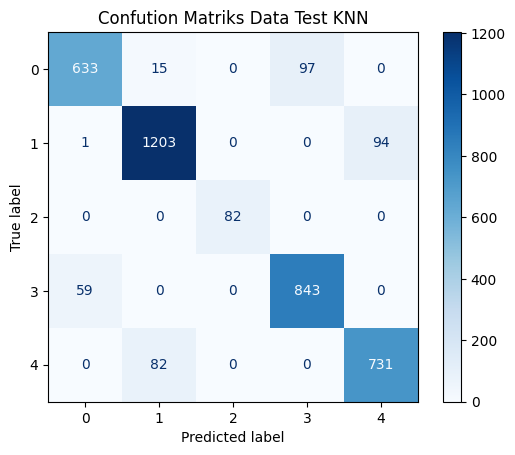

In [37]:
knn = KNeighborsClassifier(weights= 'uniform', n_neighbors = 9, metric = 'euclidean').fit(X_train_scale, y_train)
y_pred_knn = knn.predict(X_test_scale)
con_metric = confusion_matrix(y_test, y_pred_knn)
print('Classification matrik')
print(classification_report(y_test, y_pred_knn))
accuracy = accuracy_score(y_test, y_pred_knn)
print(f'Accuracy : {accuracy:.2f}')
matriks = ConfusionMatrixDisplay(confusion_matrix=con_metric, display_labels = knn.classes_)
matriks.plot(cmap='Blues')
plt.title('Confution Matriks Data Test KNN')
plt.show()

Classification matrik
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       745
           1       0.95      0.93      0.94      1298
           2       1.00      1.00      1.00        82
           3       0.93      0.94      0.93       902
           4       0.90      0.92      0.91       813

    accuracy                           0.93      3840
   macro avg       0.94      0.94      0.94      3840
weighted avg       0.93      0.93      0.93      3840

Accuracy : 0.93


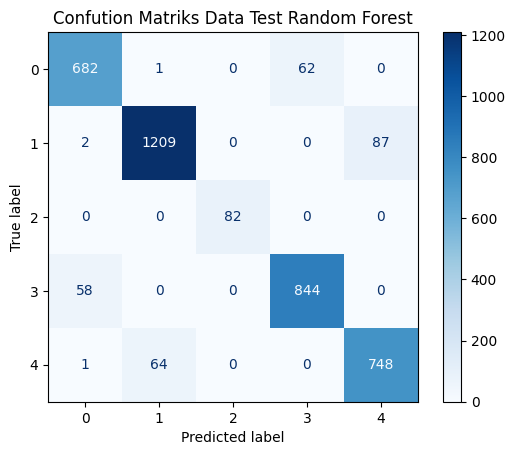

In [41]:
rf = RandomForestClassifier(n_estimators= 200, min_samples_split = 10, min_samples_leaf = 2, max_depth = 10, bootstrap = False).fit(X_train_scale, y_train)
y_pred_rf = rf.predict(X_test_scale)
con_metric = confusion_matrix(y_test, y_pred_rf)
print('Classification matrik')
print(classification_report(y_test, y_pred_rf))
accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy : {accuracy:.2f}')
matriks = ConfusionMatrixDisplay(confusion_matrix=con_metric, display_labels = rf.classes_)
matriks.plot(cmap='Blues')
plt.title('Confution Matriks Data Test Random Forest')
plt.show()

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

1. Bandingkan hasil evaluasi sebelum dan setelah tuning. <br>
Setelah dilakukan percobaan pada dua model terbaik, yaitu KNN dan Random Forest, akurasi sebelum dan sesudah dilakukan hyperparameter tuning dapat dilihat dan dibandingkan. Pada model KNN, meskipun telah dilakukan tuning dengan parameter terbaik, akurasi yang diperoleh tetap sama seperti sebelum tuning, yaitu sebesar 91%. Hal ini menunjukkan bahwa model KNN sudah berada pada konfigurasi optimal sejak awal, sehingga tuning tidak memberikan pengaruh signifikan terhadap peningkatan performa. Pada model Random Forest, terjadi peningkatan akurasi dari 91% menjadi 93% setelah dilakukan tuning. Hal ini menunjukkan bahwa proses hyperparameter tuning berhasil meningkatkan performa model secara signifikan.

2. Identifikasi kelemahan model
 - Precision atau Recall rendah untuk kelas tertentu
    * Pada model KNN, terlihat bahwa kelas 0 memiliki recall yang rendah daripada precision, yaitu hanya 0.85. Artinya, model kurang mampu menangkap semua sampel kelas 0 dengan baik, sehingga banyak instance kelas 0 yang diklasifikasikan ke kelas lain.
    * Pada model Random Forest, tidak ditemukan kelemahan signifikan karena precision dan recall relatif tinggi di semua kelas, bahkan setelah tuning. Namun, kelas 4 masih menjadi yang terendah dibandingkan kelas lain, dengan precision dan recall 0.90 dan 0.92.
 - Apakah Model Mengalami Overfitting atau Underfitting?
     * Model KNN tidak mengalami overfitting maupun underfitting, karena akurasi pada data training dan data testing relatif seimbang (sama-sama 91%).
     * Model Random Forest juga menunjukkan generalisasi yang baik. Akurasi pada data training setelah tuning sebesar 96%, dan pada data testing sebesar 93%. Meskipun terdapat sedikit gap, namun tidak signifikan dan masih dalam batas wajar, sehingga tidak menunjukkan gejala overfitting berlebihan.
 - Rekomendasi Tindakan Lanjutan :
    * Fokus pada Kelas Minoritas <br>
      Perbaiki performa di kelas 0 dan kelas 4, misalnya dengan teknik SMOTE (Synthetic Minority Over-sampling Technique)
    * Evaluasi Model:
      Fokus pada optimasi model KNN dan Random Forest yang sudah terbukti lebih unggul.
    * Feature Engineering Lebih Lanjut:
      Meninjau fitur yang digunakan, fitur yang kurang relevan bisa menyebabkan model yang kurang optimal.
    * Analisis Error:
       analisis kemungkinan penyebabnya melalui confusion matriks.